## Name: Aryan Mahesh Patil   
### RollNo: 51
#### Exp: 8              Date: 9|03|2026

In [18]:
#!pip install requests

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
def fetch_indicator(code, year="2022"):
    url=f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response=requests.get(url).json()[1]
    #{
    #"country":{"id":"IN", "value":"India"},
    #"value":2400
    #}

    data={}
    for item in response:
        country=item["country"]["value"]
        value=item["value"]
        if value is not None:
            data[country]=value
    return pd.Series(data, name=code)

In [4]:
gdp=fetch_indicator("NY.GDP.PCAP.CD")
pop=fetch_indicator("SP.POP.TOTL")
life=fetch_indicator("SP.DYN.LE00.IN")
lit=fetch_indicator("SE.ADT.LITR.ZS")

In [5]:
df=pd.concat([gdp,pop,life,lit],axis=1)

df.columns=["GDP","Population", "LifeExpectancy", "Literacy"]

df.dropna(inplace=True)

df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [6]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

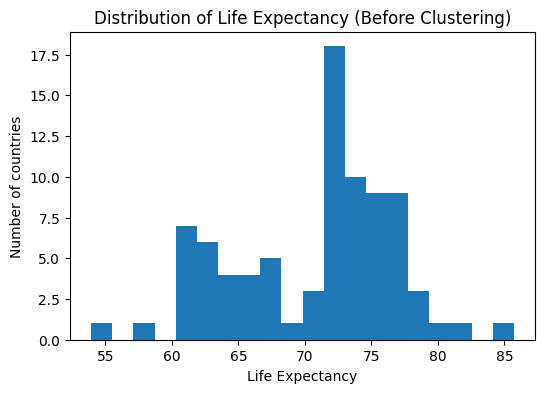

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"],bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()

In [9]:
def disp(country):
    result=df.loc[country]
    print("Country:",country)
    print("GDP:",result["GDP"])
    print("Population:",result["Population"])
    print("Life Expectancy:",result["LifeExpectancy"])
    print("Literacy Rate:",result["Literacy"])

In [10]:
disp("India")

Country: India
GDP: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242


In [11]:
disp("North America")

Country: North America
GDP: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398


In [12]:
disp("Brazil")

Country: Brazil
GDP: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348


In [13]:
disp("Viet Nam")

Country: Viet Nam
GDP: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418


In [14]:
disp("Bahrain")

Country: Bahrain
GDP: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582


k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716


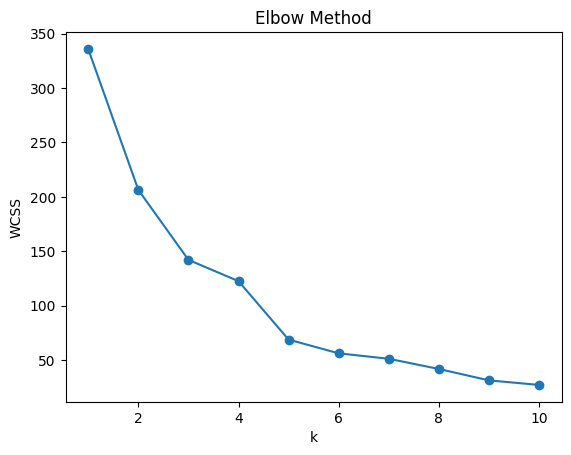

In [15]:
wcss=[]

for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1,"\t",wcss[i])

plt.plot(range(1,11),wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

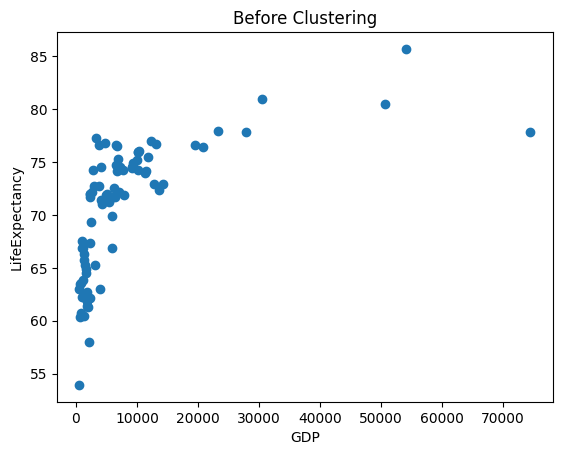

In [16]:
plt.scatter(df["GDP"],df["LifeExpectancy"])

plt.xlabel("GDP")
plt.ylabel("LifeExpectancy")
plt.title("Before Clustering")
plt.show()

In [17]:
kmeans=KMeans(n_clusters=3,random_state=0)

labels_km=kmeans.fit_predict(X_scaled)

df["KMeansCluster"]=labels_km

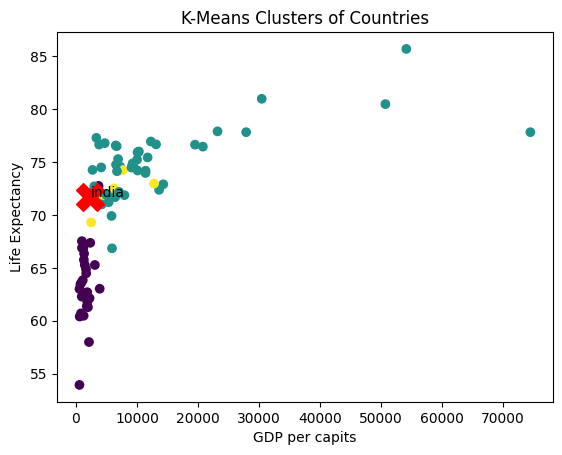

In [18]:
plt.scatter(df["GDP"],df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP per capits")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")

india=df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"], s=400, color='Red', marker='X')
plt.text(india["GDP"], india["LifeExpectancy"], "india")
plt.show()

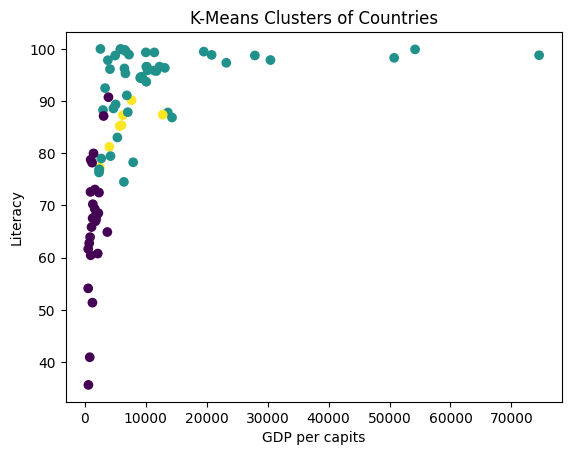

In [19]:
plt.scatter(df["GDP"],df["Literacy"], c=labels_km)
plt.xlabel("GDP per capits")
plt.ylabel("Literacy")
plt.title("K-Means Clusters of Countries")
plt.show()

In [20]:
cluster_summary=df.groupby("KMeansCluster")[["GDP","Population","LifeExpectancy","Literacy"]].mean()

print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687


In [21]:
hc=AgglomerativeClustering(n_clusters=3)
labels_hc=hc.fit_predict(X_scaled)

df["HeirarchicalCluster"]=labels_hc

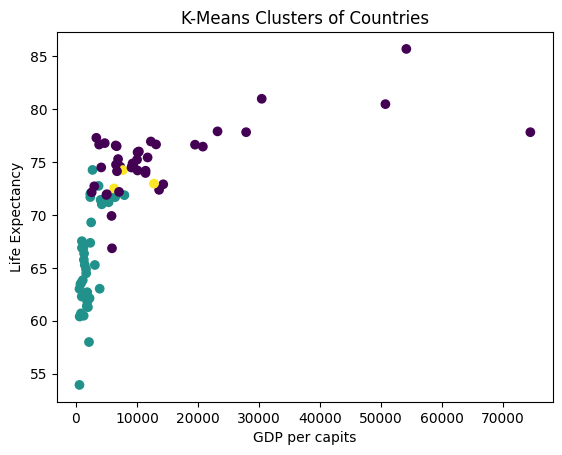

In [22]:
plt.scatter(df["GDP"],df["LifeExpectancy"], c=labels_hc)
plt.xlabel("GDP per capits")
plt.ylabel("Life Expectancy")
plt.title("K-Means Clusters of Countries")
plt.show()